In [11]:
from langchain_teddynote import logging
from langchain_core.messages import AIMessageChunk
from langchain_teddynote.messages import stream_response
from dotenv import load_dotenv

load_dotenv()
logging.langsmith("CH04-Models")

LangSmith 추적을 시작합니다.
[프로젝트명]
CH04-Models


In [16]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(model="gemini-3.5-flash")
answer=""
for token in model.stream("자연어 처리에 대해서 간략히 설명해 줘"):
    answer += token.text
    print(token.content, end="", flush=True)

[{'type': 'text', 'text': '**자연어 처리(NLP, Natural Language Processing)**는 인공지능(', 'index': 0}][{'type': 'text', 'text': 'AI)의 한 분야로, **컴퓨터가 사람의 언어(자연어)를 이해하고', 'index': 0}][{'type': 'text', 'text': ', 해석하고, 생성할 수 있도록 만드는 기술**입니다.\n\n컴퓨터는 원래 숫자(0과 1)', 'index': 0}][{'type': 'text', 'text': '만 이해하지만, 자연어 처리 기술을 통해 우리가 일상에서 쓰는 한국어, 영어 같은 복잡한 언어를 알아', 'index': 0}][{'type': 'text', 'text': '들을 수 있게 됩니다.\n\n우리 일상에서 쓰이는 대표적인 예시는 다음과 같습니다.\n\n1. **번역기:**', 'index': 0}][{'type': 'text', 'text': ' 파파고, 구글 번역 등 서로 다른 언어를 번역해 주는 기술\n2. **챗봇 및 AI', 'index': 0}][{'type': 'text', 'text': ' 비서:** ChatGPT, 시리(Siri), 빅스비 등 사람과 대화하는 기술\n3. **검', 'index': 0}][{'type': 'text', 'text': '색 엔진:** 네이버나 구글에 질문을 입력했을 때 의도를 파악하고 알맞은 결과를 보여', 'index': 0}][{'type': 'text', 'text': "주는 기술\n4. **텍스트 분석:** 수많은 제품 리뷰를 분석해 '긍정적'인지 '부정적", 'index': 0}][{'type': 'text', 'text': "'인지 자동으로 분류하는 기술 (감성 분석)\n5. **자동 완성 및 맞춤법 검사:** 글", 'index': 0}][{'type': 'text', 'text': '을 쓸 때 다음 단어를 추천하거나 틀린 맞춤법을 고쳐주는 기술\n\n요약하자면, **"', 'ind

In [ ]:
from langchain_core.prompts import PromptTemplate

prompt = PromptTemplate.from_template(
    "예/아니오 질문에 대답하세요. {question}는 과일입니까?"
)

chain = prompt | model 

answer=chain.invoke({"question":"사과"})
answer.content[0]["text"] 


In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

prompt = PromptTemplate.from_template(
    "{question}로 N행시"
)
chain = prompt | model | StrOutputParser()
answer = ""
for text in chain.stream({"question": "프롬프트 캐싱"}):
    answer+=text
    print(text, end="", flush=True)

print()

'**프롬프트 캐싱**'으로 멋지고 직관적인 6행시 두 가지 버전을 준비했습니다. 

첫 번째는 **기술의 핵심을 담은 스마트한 버전**이고, 두 번째는 **재치 있는 직장인 공감 버전**입니다.

---

### [버전 1] 스마트하고 직관적인 IT 버전

* **프**: **프**롬프트가 길어질수록 늘어나는 비용과 대기 시간,
* **롬**: **롬**목(ROM)처럼 머릿속에 기억해 두는 똑똑한 방법이 있습니다.
* **프**: **프**로세스를 획기적으로 줄여주는 이 기술은,
* **트**: **트**래픽 병목 현상 없이 서버를 시원하게 뚫어주죠.
* **캐**: **캐**시(Cache)에 미리 저장해 둔 덕분에
* **싱**: **싱**글벙글 웃음이 날 만큼 빠른 답변을 경험하게 될 것입니다!

---

### [버전 2] 센스 있는 '일잘러' 공감 버전

* **프**: **프**리패스처럼 빠르게 AI 답변을 받고 싶다면?
* **롬**: **롬**곡(눈물) 흘리며 답답해하던 느린 속도는 이제 안녕!
* **프**: **프**로 일잘러들이 이미 몰래 쓰고 있는
* **트**: **트**렌디하고 효율적인 치트키!
* **캐**: **캐**시(Cash)도 아끼고 시간도 버는 마법 같은 기술로
* **싱**: **싱**크율 100%의 완벽한 답변을 초고속으로 만나보세요.


In [ ]:
from langchain_google_genai import (
    ChatGoogleGenerativeAI,
    HarmBlockThreshold,
    HarmCategory,
)

# 구글의 Safety Setting Types 문서에는 콘텐츠 필터링 및 안전 설정과 관련된 다양한 카테고리와 임계값이 정의 되어있다.
#
llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash",
    safety_settings={
        HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT:HarmBlockThreshold.BLOCK_NONE,
        HarmCategory.HARM_CATEGORY_HATE_SPEECH: HarmBlockThreshold.BLOCK_NONE,
        HarmCategory.HARM_CATEGORY_HARASSMENT: HarmBlockThreshold.BLOCK_NONE,
        HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT: HarmBlockThreshold.BLOCK_NONE,
    }
)

In [ ]:
# from langchain_google_genai import ChatGoogleGenerativeAI

results = llm.batch(
    [
        "대한민국의 수도는?",
        "대한민국의 주요 관광지 5곳을 나열하세요.",
    ]
)

for res in results:
    print(res.text)

대한민국의 수도는 **서울**입니다.
대한민국의 대표적인 주요 관광지 5곳을 소개해 드립니다. 각 지역의 역사, 자연, 문화를 대표하는 곳들입니다.

1. **서울 경복궁 (Gyeongbokgung Palace)**
   * **특징:** 조선 왕조의 가장 대표적인 법궁(정궁)으로, 한국의 전통 건축미를 느낄 수 있는 곳입니다. 뒤편의 북악산과 어우러진 풍경이 아름다우며, 경회루와 근정전이 유명합니다. 한복을 입고 방문하면 무료입장이 가능해 국내외 관광객들에게 인기가 높습니다.

2. **제주도 성산일출봉 (Seongsan Ilchulbong, Jeju)**
   * **특징:** 유네스코 세계자연유산으로 등재된 제주의 대표적인 자연 명소입니다. 바다 위에 우뚝 솟은 거대한 사발 모양의 분화구가 장관을 이루며, 이곳에서 바라보는 일출은 대한민국에서 손꼽히는 절경입니다.

3. **경주 불국사 및 석굴암 (Bulguksa Temple & Seokguram Grotto)**
   * **특징:** 신라 천년의 역사와 찬란한 불교 예술을 보여주는 유네스코 세계문화유산입니다. 석축의 아름다움이 돋보이는 불국사와, 동양 불교 미술의 극치로 평가받는 석굴암은 한국의 역사 여행에서 빼놓을 수 없는 필수 코스입니다.

4. **부산 해운대 해수욕장 (Haeundae Beach, Busan)**
   * **특징:** 한국을 대표하는 해양 도시 부산의 랜드마크입니다. 넓은 백사장과 현대적인 빌딩 숲(마린시티)이 어우러져 이국적인 풍경을 자아냅니다. 여름철 피서지뿐만 아니라 해운대 Blue Line Park(해변열차), 엘시티 전망대 등 즐길 거리가 가득합니다.

5. **전주 한옥마을 (Jeonju Hanok Village)**
   * **특징:** 700여 채의 한옥이 도심 속에 보존되어 있는 국내 최대 규모의 전통 한옥촌입니다. 한옥 숙박 체험, 한복 대여, 그리고 전주비빔밥과 다양한 길거리 음식을 맛볼 수 있어 한국의 전통 맛과 멋을 동시에 즐길 수 있는 곳입니다.



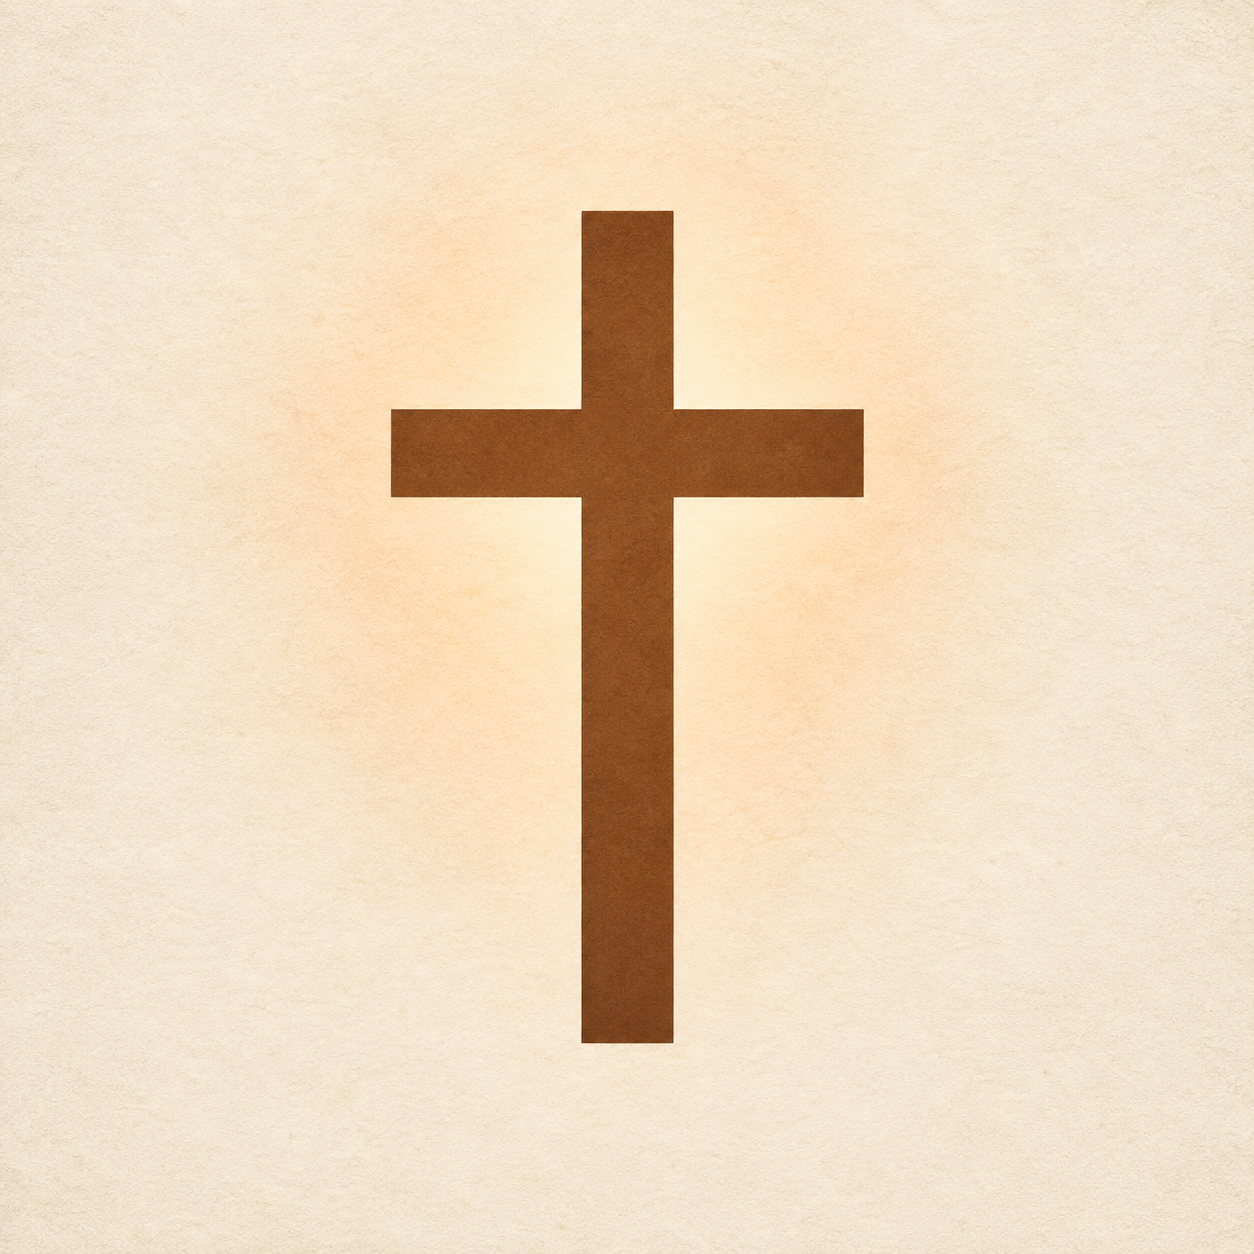

**침묵의 온기**

시간이 멈춘 듯 아늑한 벌판에
오래된 나무 한 그
루 서 있습니다.
거친 결을 품은 투박한 갈색 몸짓으로
세월의 풍
파를 견뎌낸 십자가 하나.

하늘과 땅이 가만히 맞닿고
슬
픔과 기쁨이 교차하는 그곳에서,
그는 가장 낮은 목소리로
세상의 모든 숨
소리를 듣고 있습니다.

눈부시게 찌르지 않고
그저 등 뒤에서 가만
히 번져 나와
시린 마음에 볕을 들여주는
낮고 따스한 노을빛 은
총.

말없이 서 있는 그 품속에
상처 입은 마음들이 날아와 쉬어 가고,
빛바
랜 종이 위에 번지는 향기처럼
온기는 아주 오래도록 남아 흐릅니다.

아무런 다
그침도, 화려한 꾸밈도 없이
그저 그 자리에 있어 주는 것만으로
지친 영혼
에 가만히 내려앉는
가장 고요한 위로여.




In [50]:
from langchain_teddynote.models import MultiModal
from langchain_teddynote.messages import stream_response

llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash")

system_prompt = (
    "당신은 시인입니다. 당신의 임무는 주어진 이미지를 가지고 시를 작성하는 것입니다."
)

user_prompt = "다음의 이미지에 대한 시를 작성해주세요."

multimodal_gemini = MultiModal(
    llm,system_prompt=system_prompt,user_prompt=user_prompt
)

# chain = multimodal_gemini | StrOutputParser()

IMAGE_URL = "images/cross.png"

# answer = ""
# for text in chain.stream(IMAGE_URL):
#     answer+=text
#     print(text, end="", flush=True)


answer = multimodal_gemini.stream(IMAGE_URL)
for token in answer:
    print(token.text)

In [ ]:
IMAGE_URL_ISAAC="images/isaac.png"
answer = multimodal_gemini.stream(IMAGE_URL_ISAAC)
for token in answer:
    print(token.text)